In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import math

### Напишем собственную реализацию трансформера 
(реализуем архитектуру, описанную в статье - Attention is all you need)

In [2]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim: int = 256):
        super().__init__()
        self.embed_dim = embed_dim
        
        self.q = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.k = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.v = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.scale = self.embed_dim ** 0.5 

    def forward(self, x):
        Q = self.q(x) # (B, T, D)
        K = self.k(x) # (B, T, D)
        V = self.v(x) # (B, T, D)

        qk_dot = torch.bmm(Q, K.transpose(1, 2)) # (B, T, T) - QK^T
        qk_dot = qk_dot / self.scale

        attention_scores = torch.softmax(qk_dot, dim = -1) # (B, T, T)

        out = torch.bmm(attention_scores, V)

        return out

In [3]:
class CrossAttention(nn.Module):
    def __init__(self, embed_dim: int = 256):
        super().__init__()

        self.embed_dim = embed_dim
        self.q = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.k = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.v = nn.Linear(in_features = embed_dim, out_features = embed_dim)

        self.scale = self.embed_dim ** 0.5

    def forward(self, enc_x, dec_x):
        Q = self.q(dec_x) # (B, T, D)
        K = self.k(enc_x) # (B, T, D)
        V = self.v(enc_x) # (B, T, D)

        qk_dot = torch.bmm(Q, K.transpose(1, 2))
        qk_dot = qk_dot / self.scale

        attention_scores = torch.softmax(qk_dot, dim = -1)

        out = torch.bmm(attention_scores, V)

        return out

In [4]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, num_heads: int = 6, embed_dim: int = 256):
        super().__init__()

        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // num_heads
        
        self.q = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.k = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.v = nn.Linear(in_features = embed_dim, out_features = embed_dim)
        self.out = nn.Linear(in_features = embed_dim, out_features = embed_dim)

        self.scale = self.head_dim ** 0.5

    def forward(self, query, key, value, mask = None):
        B, T, D = query.shape

        Q = self.q(query)
        K = self.k(key)
        V = self.v(value)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2) #(B, HEADS, T, HEAD_DIM)
        K = K.view(B, -1, self.num_heads, self.head_dim).transpose(1, 2) #(B, HEADS, T, HEAD_DIM)
        V = V.view(B, -1, self.num_heads, self.head_dim).transpose(1, 2) #(B, HEADS, T, HEAD_DIM)

        qk_dot = torch.matmul(Q, K.transpose(-1, -2)) / self.scale
        
        if mask is not None:
            qk_dot = qk_dot.masked_fill(mask == 0, float('-inf'))
        attention_scores = torch.softmax(qk_dot, dim = -1)

        head_out = torch.matmul(attention_scores, V)
        # contiguous - соединяем в памяти все числа в одно место - потом в view склеиваем
        head_out = head_out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(head_out)

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim: int = 256, max_len: int = 1000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * 
                             (- math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [6]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim: int = 256, dim_ff: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(in_features = embed_dim, out_features = dim_ff)
        self.linear2 = nn.Linear(in_features = dim_ff, out_features = embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x

In [7]:
class Encoder(nn.Module):
    def __init__(self, embed_dim: int = 256, dim_ff: int = 1024, num_heads: int = 6, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(num_heads, embed_dim)
        self.ff = FeedForward(embed_dim, dim_ff, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, src_mask = None):
        attn_out = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout1(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout2(ff_out))
        return x

In [8]:
class Decoder(nn.Module):
    def __init__(self, embed_dim: int = 256, dim_ff: int = 1024, num_heads: int = 6, dropout: float = 0.1):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(num_heads, embed_dim)
        self.cross_attn = MultiHeadSelfAttention(num_heads, embed_dim)
        self.ff = FeedForward(embed_dim, dim_ff, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)
    def forward(self, x, enc_out, src_mask = None, tgt_mask = None):
        attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout1(attn_out))
        cross_attn_out = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout2(cross_attn_out))
        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout3(ff_out))
        return x

In [9]:
class MyTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, 
                 embed_dim: int = 256, dim_ff: int = 1024, dropout: float = 0.1,
                num_heads: int = 8, num_layers: int = 4, pad_idx: int = 0, max_len: int = 1000):
        super().__init__()
        self.pad_idx = pad_idx

        self.src_embedding = nn.Embedding(src_vocab_size, embed_dim)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        self.pos_embedding = PositionalEncoding(embed_dim, max_len, dropout)

        self.encoder_layers = nn.ModuleList([
            Encoder(embed_dim, dim_ff, num_heads, dropout)
            for _ in range(num_layers)
        ])
        
        self.decoder_layers = nn.ModuleList([
            Decoder(embed_dim, dim_ff, num_heads, dropout)
            for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(in_features = embed_dim, out_features = tgt_vocab_size)
        self.scale = embed_dim ** 0.5
        
    def make_causal_mask(self, size, device):
        # не дает decoder'у смотреть в будущее
        mask = torch.tril(torch.ones(size, size, device = device)).bool().unsqueeze(0).unsqueeze(0)
        return mask # (1, 1, T, T)
    
    def make_pad_mask(self, seq):
        # не дает attention обращать внимание на padding-токены
        return (seq != self.pad_idx).unsqueeze(1).unsqueeze(2) # (B, 1, 1, T)

    def forward(self, src, tgt):
        src_mask = self.make_pad_mask(src)
        tgt_mask = self.make_pad_mask(tgt) & self.make_causal_mask(tgt.size(1), tgt.device)

        # Encoder
        src_emb = self.pos_embedding(self.src_embedding(src) * self.scale)
        enc_out = src_emb
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)

        tgt_emb = self.pos_embedding(self.tgt_embedding(tgt) * self.scale)
        dec_out = tgt_emb
        for layer in self.decoder_layers:
            dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)

        # проекция на словарь
        return self.fc_out(dec_out)

### Проверим данные для обучения

In [10]:
def load_cmudict(filepath):
    data = []
    with open(filepath, 'r', encoding='ascii') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';;;'):
                continue

            # split() без аргументов: разбивает по любым пробелам (один или несколько)
            tokens = line.split()
            if len(tokens) < 2:      # слово + хотя бы одна фонема
                continue

            word_with_variant = tokens[0]
            phonemes = tokens[1:]    # всё, что после слова, — список фонем

            # убираем "(1)", "(2)" и т.п.
            word = word_with_variant.split('(')[0]

            graphemes = list(word)   # ['A','B','R','E','G','O']
            data.append((graphemes, phonemes))
    return data

In [11]:
file_path = '/kaggle/input/datasets/artembez/cmudict/cmudict.dict'
all_data = load_cmudict(file_path)
print('Всего примеров:', len(all_data))

Всего примеров: 135166


### Подготовим данные для обучения

In [12]:
class Vocabulary:
    def __init__(self):
        self.vocabulary = ['<pad>', '<bos>', '<eos>', '<unk>']
        self.vocabulary.extend('abcdefghijklmnopqrstuvwxyz')
        self.vocabulary.extend('abcdefghijklmnopqrstuvwxyz'.upper())
        self.vocabulary.extend('0123456789 .,!?\'"-:;()')
        self._idx2char = {k: v for k, v in enumerate(self.vocabulary)}
        self._char2idx = {v: k for k, v in enumerate(self.vocabulary)}
    def get_vocabulary(self):
        return self.vocabulary

    def char2idx(self, char: int):
        if char not in self._char2idx:
            return self._char2idx['<unk>']
        return self._char2idx[char]

    def idx2char(self, idx: int):
        if idx not in self._idx2char:
            return '<unk>'
        return self._idx2char[idx]

    def encode(self, s):
        result = [self.char2idx(char) for char in s]
        result = [self.get_bos()] + result + [self.get_eos()]
        return result

    def decode(self, indices):
        chars = []
        for idx in indices:
            if idx == self.get_eos():
                break
            if idx in (self.get_bos(), self.get_pad()):
                continue
            chars.append(self.idx2char(idx))
        return ''.join(chars)
        
    def get_bos(self):
        return self._char2idx['<bos>']
    
    def get_eos(self):
        return self._char2idx['<eos>']
    
    def get_pad(self):
        return self._char2idx['<pad>']

    def __len__(self):
        return len(self.vocabulary)

In [13]:
class PhonemeVocabulary:
    def __init__(self, phoneme_set):
        self.vocabulary = ['<pad>', '<bos>', '<eos>', '<unk>']
        self.vocabulary.extend(sorted(phoneme_set))
        self._idx2char = {k: v for k, v in enumerate(self.vocabulary)}
        self._char2idx = {v: k for k, v in enumerate(self.vocabulary)}

    def get_vocabulary(self):
        return self.vocabulary
        
    def char2idx(self, char):
        return self._char2idx.get(char, self._char2idx['<unk>'])

    def idx2char(self, idx):
        return self._idx2char.get(idx, '<unk>')

    def encode(self, sequence):
        ids = [self._char2idx['<bos>']]
        ids += [self.char2idx(token) for token in sequence]
        ids.append(self._char2idx['<eos>'])
        return ids

    def decode(self, indices):
        tokens = []
        for idx in indices:
            if idx == self._char2idx['<eos>']:
                break
            if idx in (self._char2idx['<bos>'], self._char2idx['<pad>']):
                continue
            tokens.append(self.idx2char(idx))
        return tokens

    def get_bos(self): return self._char2idx['<bos>']
    def get_eos(self): return self._char2idx['<eos>']
    def get_pad(self): return self._char2idx['<pad>']
    def __len__(self): return len(self.vocabulary)


In [14]:
from torch.utils.data import Dataset
class G2PDataset(Dataset):
    def __init__(self, data, max_len=256):
        self.data = load_cmudict(data)                     # список кортежей (список_букв, список_фонем)
        self.src_vocab = Vocabulary()        # буквы
        # Собираем все уникальные фонемы из всего датасета
        phoneme_set = set()
        for _, phones in self.data:
            phoneme_set.update(phones)
        self.tgt_vocab = PhonemeVocabulary(phoneme_set)
        self.max_len = max_len

    def __getitem__(self, idx):
        graphemes, phonemes = self.data[idx]
        # Источник: только индексы букв (без <bos>/<eos>)
        src_ids = [self.src_vocab.char2idx(ch) for ch in graphemes[:self.max_len]]
        # Цель: индексы фонем с <bos> в начале и <eos> в конце
        tgt_ids = self.tgt_vocab.encode(phonemes[:self.max_len-2])   # -2 под BOS/EOS
        return torch.LongTensor(src_ids), torch.LongTensor(tgt_ids)

    def __len__(self):
        return len(self.data)

In [15]:
dataset = G2PDataset('/kaggle/input/datasets/artembez/cmudict/cmudict.dict')

In [16]:
dataset[100]

(tensor([ 4,  5,  5,  8, 17, 11,  4, 24, 22]),
 tensor([ 1,  9, 23, 11, 49, 38, 19, 59,  2]))

In [17]:
all_data[100]

(['a', 'b', 'b', 'e', 'n', 'h', 'a', 'u', 's'],
 ['AE1', 'B', 'AH0', 'N', 'HH', 'AW2', 'S'])

In [18]:
from torch.nn.utils.rnn import pad_sequence
pad_idx = dataset.src_vocab.get_pad()
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, padding_value = pad_idx, batch_first = True)
    tgt_padded = pad_sequence(tgt_batch, padding_value = pad_idx, batch_first = True)
    return src_padded, tgt_padded

In [19]:
src, tgt = dataset[100]
print(f'Noisy: {dataset.src_vocab.decode(src.tolist())}')
print(f'Clean: {dataset.tgt_vocab.decode(tgt.tolist())}')
print(tgt.tolist())

Noisy: abbenhaus
Clean: ['AE1', 'B', 'AH0', 'N', 'HH', 'AW2', 'S']
[1, 9, 23, 11, 49, 38, 19, 59, 2]


### Сохраним словари в файл

In [20]:
import json

In [22]:
src_vocab = dataset.src_vocab.get_vocabulary()
src_vocab_info = {'bos': dataset.src_vocab.get_bos(), 
              'eos': dataset.src_vocab.get_eos(), 
              'pad': dataset.src_vocab.get_pad(),
              'vocab_len': len(dataset.src_vocab.get_vocabulary())}
src_vocab_idxs = {}
for char in src_vocab:
    src_vocab_idxs[char] = dataset.src_vocab.char2idx(char)
src_vocab_info['vocab_idxs'] = src_vocab_idxs

In [23]:
with open('src_vocab_info.json', 'w', encoding = 'utf-8') as f:
    json.dump(src_vocab_info, f)

In [26]:
trg_vocab = dataset.tgt_vocab.get_vocabulary()
trg_vocab_info = {
    'bos': dataset.tgt_vocab.get_bos(),
    'eos': dataset.tgt_vocab.get_eos(),
    'pad': dataset.tgt_vocab.get_pad(),
    'vocab_len': len(dataset.tgt_vocab.get_vocabulary())
}
trg_vocab_idxs = {}
for char in trg_vocab:
    trg_vocab_idxs[char] = dataset.tgt_vocab.char2idx(char)
trg_vocab_info['vocab_idxs'] = trg_vocab_idxs

In [27]:
with open('trg_vocab_info.json', 'w', encoding = 'utf-8') as f:
    json.dump(trg_vocab_info, f)

### Разделим на обучающую и валидационную выборки

In [20]:
from torch.utils.data import random_split
train_dataset, valid_dataset = random_split(dataset, (int(len(dataset) * 0.85), len(dataset) - int(len(dataset)*0.85)))

In [21]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size = 64, collate_fn = collate_fn, shuffle = True, num_workers = 4, pin_memory = True)
valid_loader = DataLoader(valid_dataset, batch_size = 64, collate_fn = collate_fn, shuffle = False, num_workers = 4, pin_memory = True)

### Обучим модель

In [22]:
model = MyTransformer(src_vocab_size = len(dataset.src_vocab.get_vocabulary()), tgt_vocab_size = len(dataset.tgt_vocab.get_vocabulary()))

In [23]:
model

MyTransformer(
  (src_embedding): Embedding(78, 256)
  (tgt_embedding): Embedding(88, 256)
  (pos_embedding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder_layers): ModuleList(
    (0-3): 4 x Encoder(
      (self_attn): MultiHeadSelfAttention(
        (q): Linear(in_features=256, out_features=256, bias=True)
        (k): Linear(in_features=256, out_features=256, bias=True)
        (v): Linear(in_features=256, out_features=256, bias=True)
        (out): Linear(in_features=256, out_features=256, bias=True)
      )
      (ff): FeedForward(
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (activation): ReLU()
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
     

In [24]:
from tqdm import tqdm
from torch.nn.utils import clip_grad_norm_

def train(model):
    model.train()
    total_loss = 0
    for x, y in tqdm(train_loader, desc = 'Train'):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        tgt_input = y[:, :-1]
        tgt_output = y[:, 1:]
        
        output = model(x, tgt_input)

        loss = loss_fn(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))

        total_loss += loss.item()

        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm = 1.0)
        optimizer.step()
    total_loss /= len(train_loader)
    return total_loss

In [25]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for x, y in tqdm(loader, desc = 'Evaluation'):
        x, y = x.to(device), y.to(device)

        tgt_input = y[:, :-1]
        tgt_output = y[:, 1:]
        
        output = model(x, tgt_input)
        
        loss = loss_fn(output.reshape(-1, output.size(-1)), tgt_output.reshape(-1))
        
        total_loss += loss.item()
        
    total_loss /= len(loader)
    return total_loss

In [26]:
from IPython.display import clear_output
def plot_stats(
    train_loss_history: list[float],
    valid_loss_history: list[float],
    title: str
):
    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_loss_history, label = 'Train loss')
    plt.plot(valid_loss_history, label = 'Valid loss')
    plt.legend()
    plt.grid()
    plt.show()

In [27]:
def whole_train_value_cycle(
    model, 
    title: str, 
    num_epochs: int = 5
):
    train_loss_history = []
    valid_loss_history = []
    for epoch in range(num_epochs):
        train_loss = train(model)
        valid_loss = evaluate(model, valid_loader)
        
        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        
        clear_output()
        
        plot_stats(train_loss_history, valid_loss_history, title)

### Обучение

In [29]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


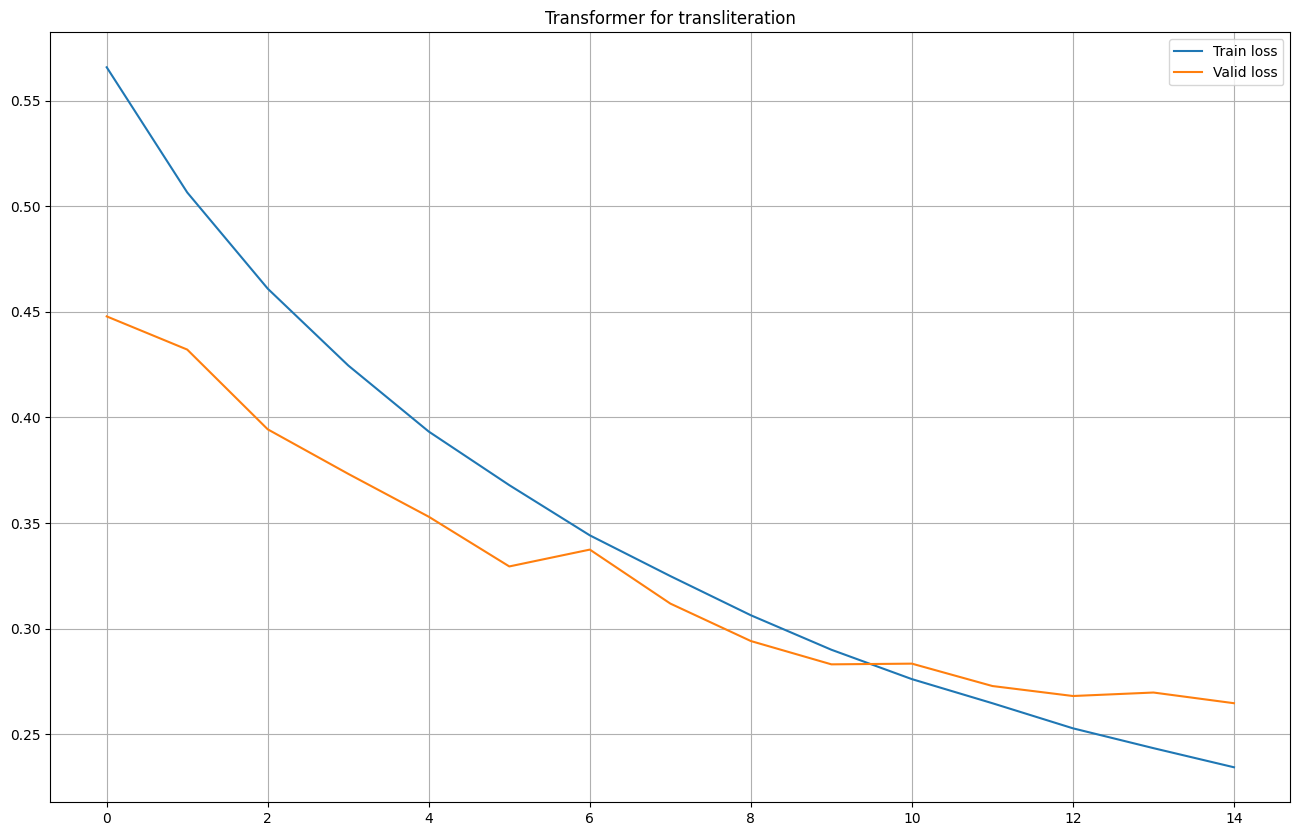

In [44]:
from torch.optim import Adam
model = model.to(device)
optimizer = Adam(model.parameters(), lr = 2e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index = pad_idx)

whole_train_value_cycle(model, 'Transformer for transliteration', 15)

In [45]:
torch.save(model.state_dict(), 'model_weights.pth')

### Проверка работы трансформера

In [46]:
import torch

def transcribe_g2p(model, src_vocab, tgt_vocab, input_string, max_len=50, device=None):
    """
    model: обученный MyTransformer
    src_vocab: Vocabulary для графем
    tgt_vocab: PhonemeVocabulary для фонем
    input_string: слово для транскрибирования
    max_len: максимальная длина выходной последовательности
    device: если None, берётся из параметров модели (авто)
    Возвращает строку фонем через пробел.
    """
    if device is None:
        # Определяем устройство, на котором находится модель
        device = next(model.parameters()).device

    model.eval()

    # 1. Подготовка источника
    graphemes = list(input_string)
    src_indices = [src_vocab.char2idx(ch) for ch in graphemes]
    src_tensor = torch.LongTensor(src_indices).unsqueeze(0).to(device)  # (1, src_len)

    bos_idx = tgt_vocab.get_bos()
    eos_idx = tgt_vocab.get_eos()

    # 2. Начинаем декодирование с токена <bos>
    tgt_indices = [bos_idx]

    for _ in range(max_len):
        tgt_tensor = torch.LongTensor(tgt_indices).unsqueeze(0).to(device)  # (1, cur_len)

        with torch.no_grad():
            logits = model(src_tensor, tgt_tensor)          # (1, cur_len, tgt_vocab_size)
            next_token_logits = logits[0, -1, :]            # логиты последней позиции
            next_token = next_token_logits.argmax(dim=-1).item()

        tgt_indices.append(next_token)
        if next_token == eos_idx:
            break

    # 3. Декодируем индексы в строку фонем (исключая служебные токены)
    phoneme_list = tgt_vocab.decode(tgt_indices)
    return ' '.join(phoneme_list)

In [55]:
word = "cucumber"
transcription = transcribe_g2p(model, dataset.src_vocab, dataset.tgt_vocab, word)
print(f"Слово: {word}")
print(f"Транскрипция: {transcription}")

Слово: cucumber
Транскрипция: K Y UW1 K AH0 M B ER0
